# 🔁 Day 3 — Backpropagation, Gradient Descent & Optimizers

**Phase 3 — Sprint 1: Deep Learning Introduction**

This notebook follows the Week 6 Day 3 curriculum: the four-step training loop, gradient descent, learning rate, backpropagation, optimizers, epochs, batches, and the required learning-rate experiment.

## 🎯 Learning Objectives

- Describe the four-step neural-network training loop.
- Explain gradient descent and the role of the learning rate.
- Explain backpropagation conceptually and the role of the chain rule.
- Name common optimizers and explain epochs and batches.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)
print("NumPy:",np.__version__)
print("Pandas:",pd.__version__)

NumPy: 2.4.4
Pandas: 3.0.2


## 📂 1. Project Context — Fraud Detection

The Phase 3 project uses the real `creditcard.csv` dataset. Day 3 focuses on training mechanics, so a tiny controlled network is used for the learning-rate experiment; this avoids presenting a toy experiment as project performance.

In [2]:
# 📥 Load the dataset: local file first, then Google Drive as a fallback
# (the full dataset is ~98MB, too large to commit to GitHub directly,
# so it's hosted on Google Drive and downloaded here at runtime)
from pathlib import Path

DATA_PATH = Path("creditcard.csv")

if not DATA_PATH.exists():
    try:
        import gdown
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "-q", "gdown"], check=True)
        import gdown

    GDRIVE_FILE_ID = "1UZ3hAYkcXulu8MSdZQiSzpgb1qu4bXNh"
    gdown.download(
        f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}",
        str(DATA_PATH),
        quiet=False,
    )

if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/creditcard.csv")

df = pd.read_csv(DATA_PATH)
print(f"Using dataset: {DATA_PATH}")
print("Dataset shape:", df.shape)
print("Target classes:", sorted(df["Class"].unique().tolist()))
print("\nClass distribution:")
print(df["Class"].value_counts().sort_index())
assert df["Class"].nunique() == 2
assert set(df["Class"].unique()) == {0, 1}


Using dataset: creditcard.csv
Dataset shape: (284807, 31)
Target classes: [0, 1]

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## 🔄 2. The Four-Step Training Loop

**Forward → Loss → Backprop → Update**

1. **Forward pass:** use current parameters to make predictions.
2. **Loss:** measure how wrong the predictions are.
3. **Backpropagation:** work backward from the loss and calculate gradients showing how parameters contributed to the error.
4. **Update:** use the gradients to change parameters in a direction that reduces loss.

The loop repeats over batches and epochs.

### 🧩 Training Loop in One Picture

```text
Input → Forward pass → Prediction → Loss → Backpropagation → Gradients → Weight update → Repeat
```

**Backpropagation computes gradients; the optimizer applies the update.**

## ⛰️ 3. Gradient Descent and the Loss Surface

The gradient points toward the direction of steepest increase in loss. Gradient descent moves in the opposite direction, downhill, to reduce loss. The learning rate controls the size of the step.

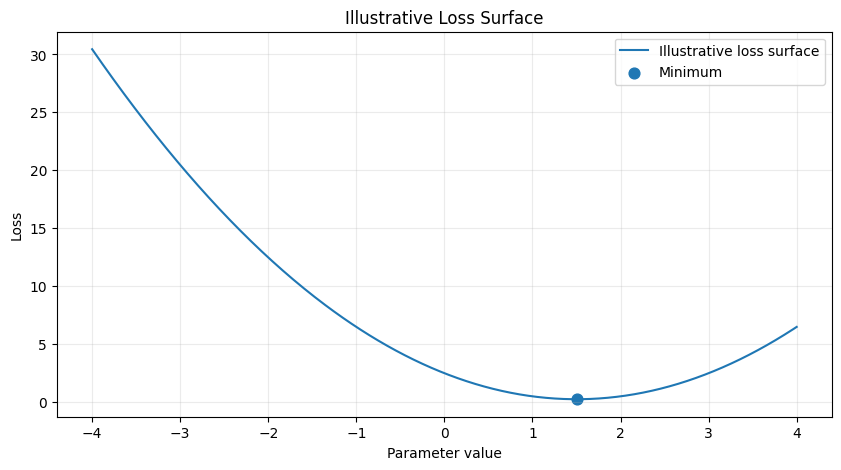

In [3]:
w=np.linspace(-4,4,400)
loss=(w-1.5)**2+0.2
plt.figure(figsize=(10,5))
plt.plot(w,loss,label="Illustrative loss surface")
plt.scatter([1.5],[0.2],s=60,label="Minimum")
plt.title("Illustrative Loss Surface")
plt.xlabel("Parameter value"); plt.ylabel("Loss"); plt.legend(); plt.grid(alpha=.25); plt.show()

## 🎚️ 4. Learning Rate

| Learning rate | Effect |
|---|---|
| Too high | Can overshoot the minimum; loss may bounce or diverge |
| Too low | Training is very slow and may make little progress |
| Just right | More stable and efficient decrease in loss |

The curriculum recommends Adam as a strong default and suggests starting around **0.001**, then adjusting if the loss curve misbehaves.

## 🧠 5. Backpropagation & the Chain Rule

Backpropagation works backward from the loss and efficiently computes the gradient of the loss with respect to trainable parameters. The **chain rule** connects the local derivatives through the sequence of operations in the network.

A useful intuition is **assigning blame**: backpropagation determines how much each parameter contributed to the final error. Frameworks such as TensorFlow and PyTorch automate this calculation.

## ⚙️ 6. Optimizers, Epochs & Batches

| Term | Meaning |
|---|---|
| Optimizer | Algorithm that applies gradient-based updates |
| Epoch | One complete pass through the training dataset |
| Batch | Subset processed before a parameter update |
| SGD | Basic stochastic gradient-descent optimizer |
| Adam | Adaptive optimizer that adjusts step sizes per parameter |

## 🖥️ Hands-On Lab — Understanding Training + Mentor Review

### Step 1 — Four-step training loop
**Forward → Loss → Backprop → Update.** This is the repeated cycle used to improve the network.

### Step 2 — Three learning rates
The following tiny model makes the effect of learning rate visible.

In [4]:
# Tiny controlled model: y_hat = Xw+b, trained with gradient descent on MSE
X=np.array([[1.],[2.],[3.],[4.]])
y=np.array([[2.],[4.],[6.],[8.]])
def train(lr,epochs=40):
    w=np.array([[0.]])
    b=np.array([[0.]])
    losses=[]
    for _ in range(epochs):
        pred=X@w+b
        err=pred-y
        losses.append(float(np.mean(err**2)))
        dw=(2/len(X))*(X.T@err)
        db=(2/len(X))*np.sum(err)
        w-=lr*dw
        b-=lr*db
    return np.array(losses),float(w[0,0]),float(b[0,0])

settings={"Too low":.001,"Good":.01,"Too high":.5}
results={}
for name,lr in settings.items():
    losses,w,b=train(lr)
    results[name]=(losses,w,b)
    print(f"{name} | lr={lr} | initial={losses[0]:.6f} | final={losses[-1]:.6f} | w={w:.6f} | b={b:.6f}")

Too low | lr=0.001 | initial=30.000000 | final=8.109091 | w=0.881148 | b=0.291599
Good | lr=0.01 | initial=30.000000 | final=0.049158 | w=1.814862 | b=0.540392
Too high | lr=0.5 | initial=30.000000 | final=1116963630935596069109432761623455764789136905954062891617022210211840.000000 | w=-80482842616288434301594428021669888.000000 | b=-27373981105448625495714703228272640.000000


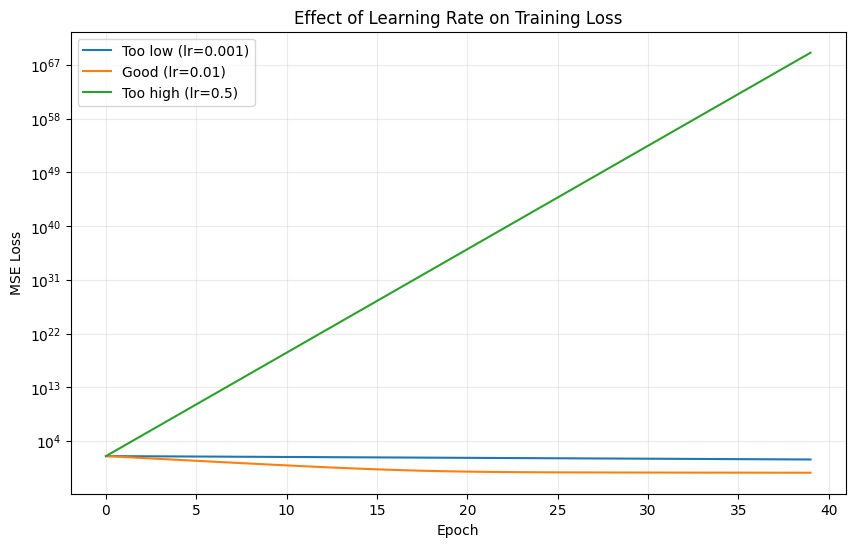

In [5]:
plt.figure(figsize=(10,6))
for name,(losses,w,b) in results.items():
    plt.plot(losses,label=f"{name} (lr={settings[name]})")
plt.title("Effect of Learning Rate on Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.yscale("log"); plt.legend(); plt.grid(alpha=.25); plt.show()

In [6]:
for name,(losses,_,_) in results.items():
    assert np.isfinite(losses).all()
assert results["Good"][0][-1] < results["Good"][0][0]
assert results["Too high"][0][-1] > results["Good"][0][-1]
print("Learning-rate sanity checks: PASSED")

Learning-rate sanity checks: PASSED


### 📌 Interpretation

The **too-low** learning rate takes very small steps, so improvement is slow. The **good** rate produces steady progress. The deliberately **too-high** rate takes aggressive steps and overshoots instead of settling efficiently. These are results from the controlled experiment, not Fraud Detection performance metrics.

### Step 3 — Backpropagation in My Own Words

Backpropagation starts at the loss and moves backward through the network, calculating how the loss changes with respect to each trainable parameter. The chain rule is needed because an earlier parameter affects the final loss through a sequence of operations; multiplying the relevant local derivatives connects those effects.

### Step 4 — Mentor Code & Notebook Review

The current project notebook should be committed to the correct feature branch and opened as a pull request for the mid-sprint Mentor Code & Notebook Review. Review points: executable notebook, clear training-loop explanation, visible learning-rate curves, understandable backpropagation/chain-rule explanation, documented results, and clear Markdown. Any mentor feedback should be addressed before Sprint Review.

## 🔬 Objective → Evidence Mapping

| Objective | Evidence |
|---|---|
| Training loop | Forward → Loss → Backprop → Update explanation |
| Gradient descent | Loss-surface illustration and explanation |
| Learning rate | Three-rate experiment and loss curves |
| Backpropagation | Conceptual explanation and chain-rule connection |
| Optimizers | SGD and Adam comparison |
| Epochs/batches | Definitions table |
| Hands-On Lab | All four required steps included |

## 💭 Reflection

The key distinction from today is that backpropagation and the optimizer are different: backpropagation calculates gradients, while the optimizer uses them to update parameters. The learning-rate experiment also shows why the loss curve is evidence for diagnosing training behavior rather than just reporting a final number.

## 🚀 Beyond the Requirement

For the Fraud Detection project, training diagnostics should be treated as evidence. If the loss behaves poorly, the curve can indicate that the learning rate or another training setting needs attention. This connects today's mechanics directly to the TensorFlow/Keras implementation on Day 4.

In [7]:
# Final reproducibility and sanity checks
assert RANDOM_STATE==42
assert len(df)>0
assert df["Class"].nunique()==2
assert all(np.isfinite(v[0]).all() for v in results.values())
print("Final notebook sanity checks: PASSED")
print("Project rows:",len(df))
print("Project classes:",sorted(df["Class"].unique().tolist()))

Final notebook sanity checks: PASSED
Project rows: 284807
Project classes: [0, 1]


## ✅ Day 3 Completion

- [x] Four-step training loop explained
- [x] Gradient descent and loss surface covered
- [x] Learning rate explained
- [x] Three learning rates tested and plotted
- [x] Backpropagation and chain rule explained
- [x] Adam and SGD covered
- [x] Epochs and batches covered
- [x] 🖥️ Hands-On Lab completed as a separate section
- [x] Mentor Review preparation documented
- [x] Reproducibility and sanity checks included